## (0) Settings and Functions

In [1]:
%load_ext autotime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    KFold, RepeatedKFold, cross_validate, learning_curve, train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    make_scorer, accuracy_score, f1_score, precision_score,
    recall_score, hamming_loss
)

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.base import clone

from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from collections import Counter

import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings(
    "ignore",
    category=UndefinedMetricWarning
)

time: 10.6 s (started: 2026-02-11 16:39:44 -03:00)


In [2]:
df = pd.read_csv("../../data/treated/go_emotions_treated.csv")

print(df.shape)
df.head(3)

(54234, 41)


,id,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,UNCLEAN_TEXT_PT,BASE_TEXT_PT,TEXT_NO_STOP_PT,TEXT_LEMMA_PT,CLEAN_TEXT_PT,UNCLEAN_TEXT_EN,BASE_TEXT_EN,TEXT_NO_STOP_EN,TEXT_LEMMA_EN,CLEAN_TEXT_EN
0,eczazk6,0,0,0,0,1,0,0,0,0,...,Tão rápido quanto [NOME] me carregará. Seriame...,tao rapido quanto nome carregara seriamente up...,tao rapido nome carregara seriamente uptown ce...,tao rapido quanto nome carregar seriamente upt...,tao rapido nome carregar seriamente uptown cen...,Fast as [NAME] will carry me. Seriously uptown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...,fast name will carry seriously uptown downtown...
1,eczb07q,0,0,0,0,0,0,0,0,0,...,Você estragou isso. Eles tocaram você como um ...,voce estragou isso eles tocaram voce como violino,voce estragou tocaram voce violino,voce estragar isso eles tocar voce como violino,voce estragar tocar voce violino,You blew it. They played you like a fiddle.,you blew they played you like fiddle,you blew they played you like fiddle,you blew they played you like fiddle,you blew they played you like fiddle
2,eczb4bm,0,0,0,0,0,0,0,0,0,...,TL;DR Não há mais Super Bowls para [NAME]. Pre...,nao mais super bowls para name prepare-se para...,nao super bowls name prepare-se temporada vito...,nao mais super bowl para name preparar se para...,nao super bowl name preparar se temporada vito...,TL;DR No more Superbowls for [NAME]. Get ready...,more superbowls for name get ready for another...,more superbowls name get ready another winning...,more superbowls ser name get ready ser another...,more superbowls name get ready another winning...


time: 717 ms (started: 2026-02-11 16:39:54 -03:00)


In [3]:
def evaluate_cv(model, X_train, y_train, n_splits=5, n_repeats=6):
    rskf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    hamming_scorer = make_scorer(
        hamming_loss,
        greater_is_better=False
    )

    # macro: trata todas as classes igualmente (classes raras importam tanto quanto classes frequentes)
    # weighted: melhor se houver desbalanceamento (penaliza menos erros em classes raras)
    scoring = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted',
        'f1_micro': 'f1_micro',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'hamming_loss': hamming_scorer
    }

    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=rskf,
        scoring=scoring,
    )

    accuracy_scores = results['test_accuracy']
    precision_scores = results['test_precision_macro']
    recall_scores  = results['test_recall_macro']
    f1_macro_scores = results['test_f1_macro']
    f1_weighted_scores = results['test_f1_weighted']
    f1_micro_scores = results['test_f1_micro']
    hamming_scores = results['test_hamming_loss']

    return {
        "Accuracy":  (accuracy_scores.mean(),  accuracy_scores.std(),  accuracy_scores),
        "Precision_macro": (precision_scores.mean(), precision_scores.std(), precision_scores),
        "Recall_macro":  (recall_scores.mean(),  recall_scores.std(),  recall_scores),
        "F1_macro":   (f1_macro_scores.mean(),   f1_macro_scores.std(),   f1_macro_scores),
        "F1_weighted":   (f1_weighted_scores.mean(),   f1_weighted_scores.std(),   f1_weighted_scores),
        "F1_micro":   (f1_micro_scores.mean(),   f1_micro_scores.std(),   f1_micro_scores),
        "Hamming_loss":   (-hamming_scores.mean(),   hamming_scores.std(),   hamming_scores),
    }

def plot_learning_curve(model, X_train, y_train, model_name, cv=5, scoring='f1_macro'):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=KFold(n_splits=cv, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring=scoring
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
    plt.plot(train_sizes, valid_mean, 'o-', color="orange", label="Validation Score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="orange")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel(scoring)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_feature_importance_top_k(model, feature_names, k=15, model_name="Model"):
    if not hasattr(model, "feature_importances_"):
        raise ValueError("Model does not expose feature_importances_")
    
    importances = model.feature_importances_

    if importances.ndim == 2:
        importances = importances.mean(axis=0)

    idx_sorted = np.argsort(importances)[::-1][:k]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(k), importances[idx_sorted][::-1])
    plt.yticks(range(k), np.array(feature_names)[idx_sorted][::-1])
    plt.title(f"Top-{k} Feature Importances (avg) - {model_name}")
    plt.xlabel("Mean Importance across labels")
    plt.tight_layout()
    plt.show()

time: 2.24 ms (started: 2026-02-11 16:39:55 -03:00)


## (1) SMOTE por label (Binary Relevance)

In [4]:
def evaluate_cv_smote_per_label(base_model, X_text, y, emotion_cols, n_splits=5, n_repeats=6, random_state=42):
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)

    metrics = {
        "accuracy": [],
        "precision_macro": [],
        "recall_macro": [],
        "f1_macro": [],
        "f1_weighted": [],
        "f1_micro": [],
    }

    for label_idx, label_name in enumerate(emotion_cols):
        print(f" → Label: {label_name}")

        y_label = y[:, label_idx]

        for train_idx, test_idx in rkf.split(X_text):
            X_train, X_test = X_text.iloc[train_idx], X_text.iloc[test_idx]
            y_train, y_test = y_label[train_idx], y_label[test_idx]

            vectorizer = CountVectorizer()
            X_train_vec = vectorizer.fit_transform(X_train)
            X_test_vec = vectorizer.transform(X_test)

            if len(np.unique(y_train)) > 1:
                smote = SMOTE(random_state=random_state)
                X_train_vec, y_train = smote.fit_resample(
                    X_train_vec, y_train
                )

            clf = clone(base_model)
            clf.fit(X_train_vec, y_train)

            y_pred = clf.predict(X_test_vec)

            metrics["accuracy"].append(
                accuracy_score(y_test, y_pred)
            )
            metrics["precision_macro"].append(
                precision_score(y_test, y_pred, zero_division=0)
            )
            metrics["recall_macro"].append(
                recall_score(y_test, y_pred, zero_division=0)
            )
            metrics["f1_macro"].append(
                f1_score(y_test, y_pred, average="macro", zero_division=0)
            )
            metrics["f1_weighted"].append(
                f1_score(y_test, y_pred, average="weighted", zero_division=0)
            )
            metrics["f1_micro"].append(
                f1_score(y_test, y_pred, average="micro", zero_division=0)
            )

    results = {
        "Accuracy": (
            np.mean(metrics["accuracy"]),
            np.std(metrics["accuracy"]),
            np.array(metrics["accuracy"])
        ),
        "Precision_macro": (
            np.mean(metrics["precision_macro"]),
            np.std(metrics["precision_macro"]),
            np.array(metrics["precision_macro"])
        ),
        "Recall_macro": (
            np.mean(metrics["recall_macro"]),
            np.std(metrics["recall_macro"]),
            np.array(metrics["recall_macro"])
        ),
        "F1_macro": (
            np.mean(metrics["f1_macro"]),
            np.std(metrics["f1_macro"]),
            np.array(metrics["f1_macro"])
        ),
        "F1_weighted": (
            np.mean(metrics["f1_weighted"]),
            np.std(metrics["f1_weighted"]),
            np.array(metrics["f1_weighted"])
        ),
        "F1_micro": (
            np.mean(metrics["f1_micro"]),
            np.std(metrics["f1_micro"]),
            np.array(metrics["f1_micro"])
        )
    }

    return results

def plot_learning_curve_smote_per_label(base_model, X_text, y, emotion_cols, model_name, train_sizes=np.linspace(0.2, 1.0, 10), n_splits=5, random_state=42):
    rng = np.random.RandomState(random_state)

    train_scores_mean = []
    train_scores_std = []
    val_scores_mean = []
    val_scores_std = []

    n_samples = len(X_text)

    for frac in train_sizes:
        size = int(frac * n_samples)

        idx_subset = rng.choice(n_samples, size=size, replace=False)
        X_subset = X_text.iloc[idx_subset]
        y_subset = y[idx_subset]

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

        train_scores = []
        val_scores = []

        for train_idx, val_idx in kf.split(X_subset):
            X_train, X_val = X_subset.iloc[train_idx], X_subset.iloc[val_idx]
            y_train, y_val = y_subset[train_idx], y_subset[val_idx]

            f1_train_all = []
            f1_val_all = []

            for label_idx in range(len(emotion_cols)):
                y_train_lbl = y_train[:, label_idx]
                y_val_lbl = y_val[:, label_idx]

                vectorizer = CountVectorizer()
                X_train_vec = vectorizer.fit_transform(X_train)
                X_val_vec = vectorizer.transform(X_val)

                if len(np.unique(y_train_lbl)) > 1:
                    smote = SMOTE(random_state=random_state)
                    X_train_vec, y_train_lbl = smote.fit_resample(
                        X_train_vec, y_train_lbl
                    )

                clf = clone(base_model)
                clf.fit(X_train_vec, y_train_lbl)

                y_train_pred = clf.predict(X_train_vec)
                y_val_pred = clf.predict(X_val_vec)

                f1_train_all.append(
                    f1_score(y_train_lbl, y_train_pred, average="macro", zero_division=0)
                )
                f1_val_all.append(
                    f1_score(y_val_lbl, y_val_pred, average="macro", zero_division=0)
                )

            train_scores.append(np.mean(f1_train_all))
            val_scores.append(np.mean(f1_val_all))

        train_scores_mean.append(np.mean(train_scores))
        train_scores_std.append(np.std(train_scores))
        val_scores_mean.append(np.mean(val_scores))
        val_scores_std.append(np.std(val_scores))

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes * n_samples, train_scores_mean, "o-", label="Training F1-macro")
    plt.plot(train_sizes * n_samples, val_scores_mean, "o-", label="Validation F1-macro")

    plt.fill_between(
        train_sizes * n_samples,
        np.array(train_scores_mean) - np.array(train_scores_std),
        np.array(train_scores_mean) + np.array(train_scores_std),
        alpha=0.1
    )

    plt.fill_between(
        train_sizes * n_samples,
        np.array(val_scores_mean) - np.array(val_scores_std),
        np.array(val_scores_mean) + np.array(val_scores_std),
        alpha=0.1
    )

    plt.title(f"Learning Curve (SMOTE) - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1-macro")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_rf_feature_importance_smote( X_text, y, emotion_cols, k=15, random_state=42):
    all_importances = []
    feature_names_ref = None

    for label_idx, label_name in enumerate(emotion_cols):
        y_label = y[:, label_idx]

        vectorizer = CountVectorizer()
        X_vec = vectorizer.fit_transform(X_text)

        if len(np.unique(y_label)) > 1:
            smote = SMOTE(random_state=random_state)
            X_vec, y_label = smote.fit_resample(X_vec, y_label)

        rf = RandomForestClassifier(
            n_estimators=200,
            random_state=random_state,
            n_jobs=-1
        )
        rf.fit(X_vec, y_label)

        importances = rf.feature_importances_

        if feature_names_ref is None:
            feature_names_ref = vectorizer.get_feature_names_out()

        all_importances.append(importances)

    mean_importances = np.mean(all_importances, axis=0)

    idx_sorted = np.argsort(mean_importances)[::-1][:k]

    plt.figure(figsize=(10, 6))
    plt.barh(
        range(k),
        mean_importances[idx_sorted][::-1]
    )
    plt.yticks(
        range(k),
        feature_names_ref[idx_sorted][::-1]
    )
    plt.title(f"Top-{k} Feature Importances (avg across labels) - RandomForest")
    plt.xlabel("Mean Importance")
    plt.tight_layout()
    plt.show()

time: 4.15 ms (started: 2026-02-11 16:39:55 -03:00)


In [5]:
df['BASE_TEXT_EN'] = (
    df['BASE_TEXT_EN']
    .fillna("")
    .astype(str)
)

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

X_text = df['BASE_TEXT_EN']
y = df[emotion_cols].values

X_text_train, X_text_aux, y_train, y_aux = train_test_split(
    X_text, y,
    train_size=0.70,
    random_state=42,
)

X_text_dev, X_text_test, y_dev, y_test = train_test_split(
    X_text_aux, y_aux,
    train_size=0.50,
    random_state=42,
)

print(X_text_train.shape, X_text_dev.shape, X_text_test.shape)

(37963,) (8135,) (8136,)
time: 24.1 ms (started: 2026-02-11 16:39:55 -03:00)


Antes: Counter({np.int64(0): 37891, np.int64(1): 72})
Depois: Counter({np.int64(0): 37891, np.int64(1): 37891})


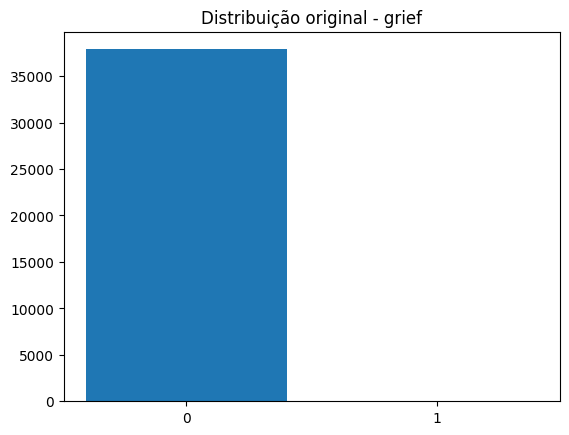

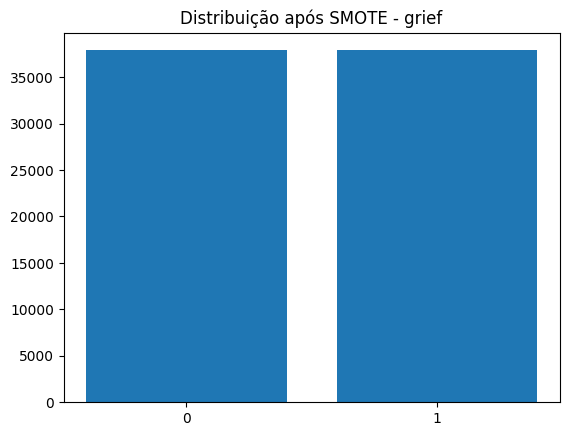

time: 451 ms (started: 2026-02-10 20:58:15 -03:00)


In [37]:
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(X_text_train)

emotion = "grief"
emotion_idx = emotion_cols.index(emotion)

y_emotion = y_train[:, emotion_idx]

print("Antes:", Counter(y_emotion))

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_bow, y_emotion)

print("Depois:", Counter(y_res))

plt.bar(["0", "1"], Counter(y_emotion).values())
plt.title("Distribuição original - grief")
plt.show()

plt.bar(["0", "1"], Counter(y_res).values())
plt.title("Distribuição após SMOTE - grief")
plt.show()


Running model: LogisticRegression


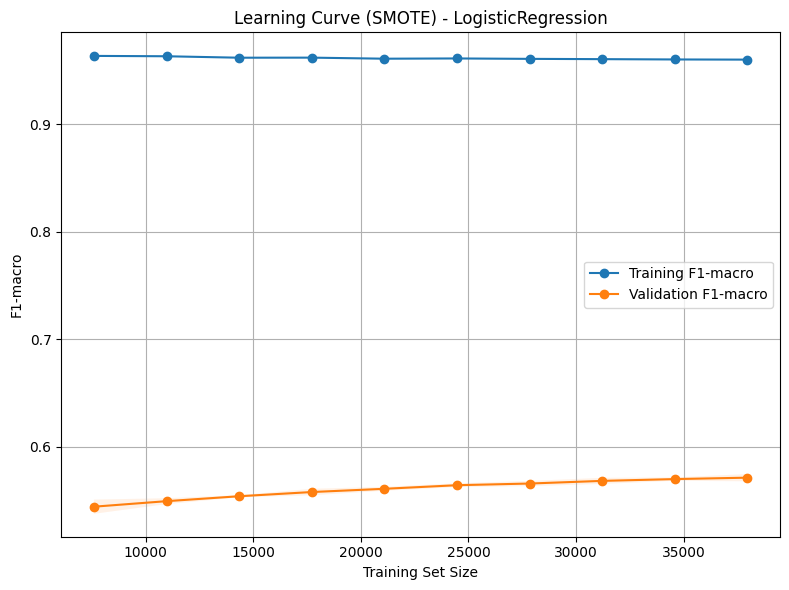


Running model: RidgeClassifier


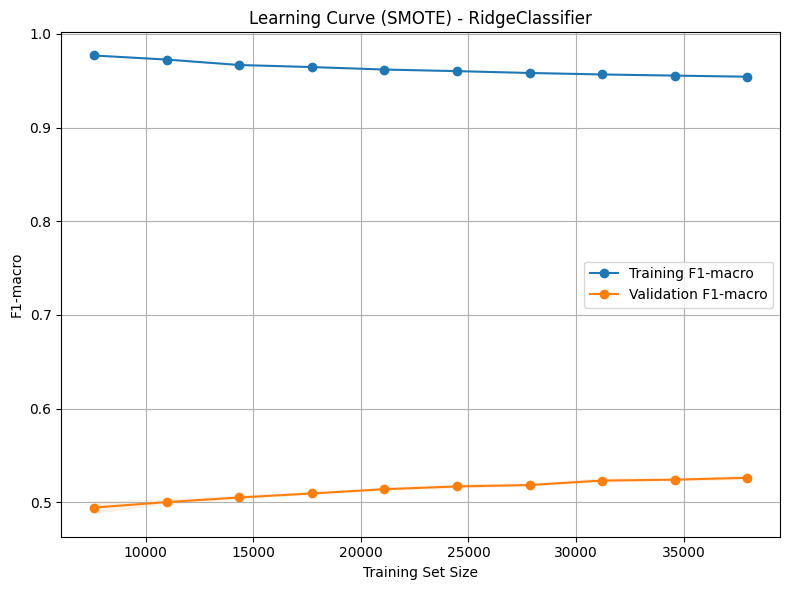


Running model: LinearSVC


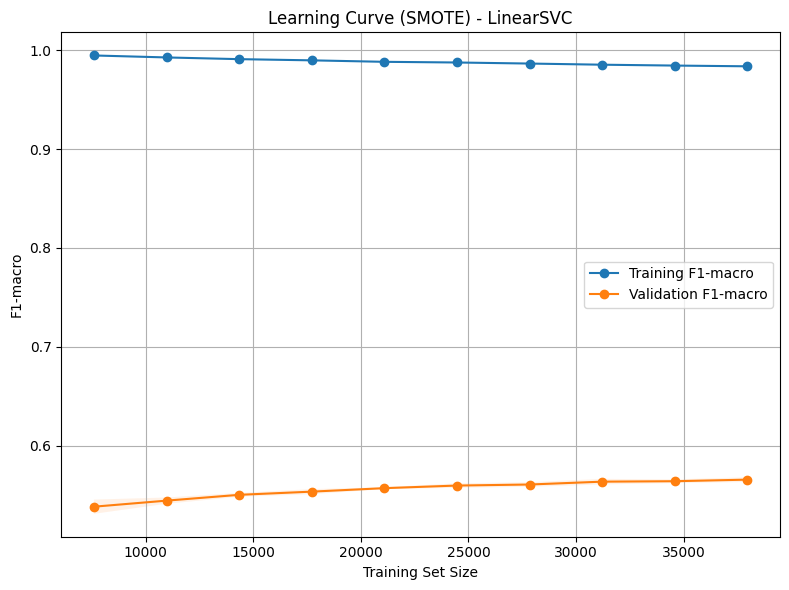


Running model: RandomForest


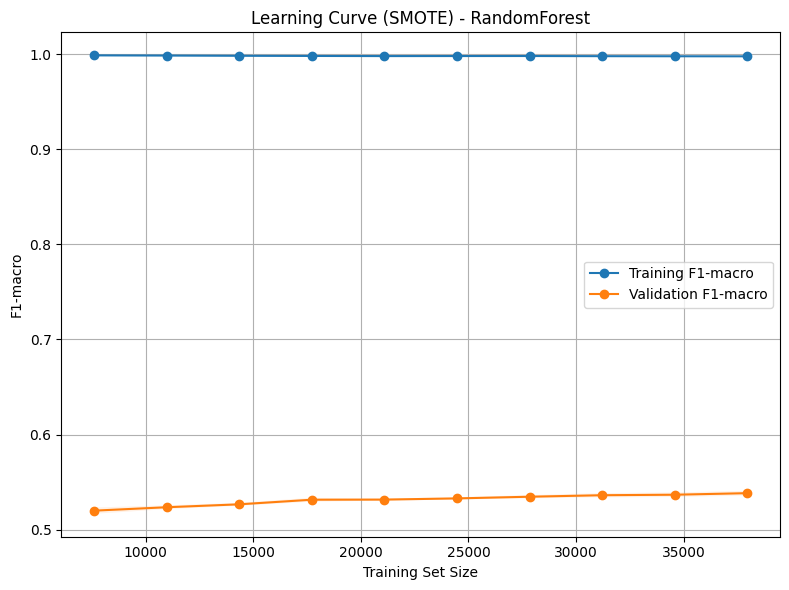


Running model: XGBClassifier


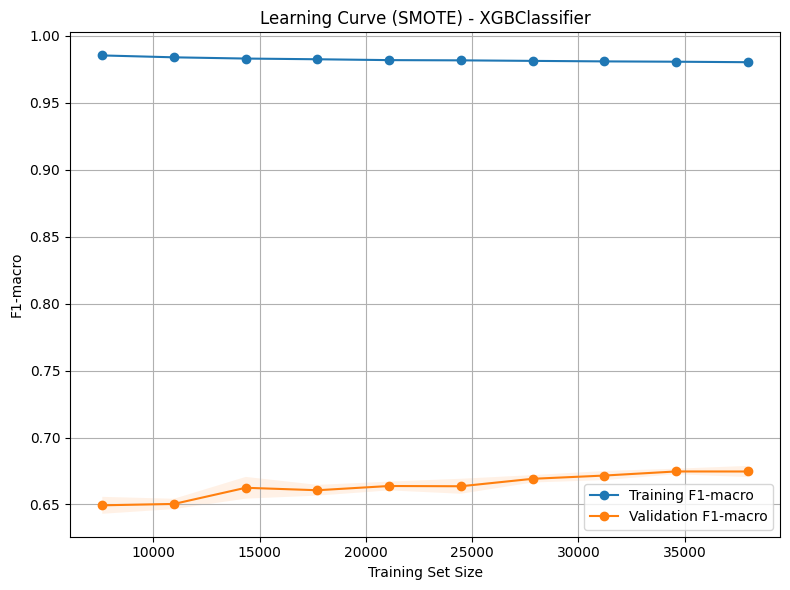

time: 11h 39min 53s (started: 2026-02-11 16:39:57 -03:00)


In [6]:
models_for_testing = {
    "LogisticRegression": OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": OneVsRestClassifier(
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            verbosity=0
    ))
}

# results = []

def run_predictions(name, model, X_text_train, y_train):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print("=" * 80)

    # cv_res = evaluate_cv_smote_per_label(
    #     base_model=model,
    #     X_text=X_text_train,
    #     y=y_train,
    #     emotion_cols=emotion_cols,
    #     n_splits=5,
    #     n_repeats=6
    # )

    plot_learning_curve_smote_per_label(
        base_model=model,
        X_text=X_text_train,
        y=y_train,
        emotion_cols=emotion_cols,
        model_name=name
    )

    # results.append({
    #     "Model": name,

    #     "CV_Accuracy_mean":  cv_res["Accuracy"][0],
    #     "CV_Accuracy_std":   cv_res["Accuracy"][1],
    #     "CV_Accuracy_all":   cv_res["Accuracy"][2],

    #     "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
    #     "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
    #     "CV_Precision_macro_all":   cv_res["Precision_macro"][2],

    #     "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
    #     "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
    #     "CV_Recall_macro_all":   cv_res["Recall_macro"][2],

    #     "CV_F1_macro_mean":  cv_res["F1_macro"][0],
    #     "CV_F1_macro_std":   cv_res["F1_macro"][1],
    #     "CV_F1_macro_all":   cv_res["F1_macro"][2],

    #     "CV_F1_weighted_mean":  cv_res["F1_weighted"][0],
    #     "CV_F1_weighted_std":   cv_res["F1_weighted"][1],
    #     "CV_F1_weighted_all":   cv_res["F1_weighted"][2],

    #     "CV_F1_micro_mean":  cv_res["F1_micro"][0],
    #     "CV_F1_micro_std":   cv_res["F1_micro"][1],
    #     "CV_F1_micro_all":   cv_res["F1_micro"][2]
    # })

for name, model in models_for_testing.items():
    run_predictions(name, model, X_text_train, y_train)

In [39]:
df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_macro_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)

Best model: XGBClassifier
time: 3.57 ms (started: 2026-02-11 10:10:51 -03:00)


In [40]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        # Remove as colunas originais
        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    # reorganiza colunas
    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/balanced/balanced_05_GoEmotions_BoW_SMOTE.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,F1_micro
LogisticRegression,0.8929 ± 0.0508,0.1509 ± 0.1632,0.3896 ± 0.1752,0.5714 ± 0.087,0.9175 ± 0.0506,0.8929 ± 0.0508
RidgeClassifier,0.8064 ± 0.059,0.1183 ± 0.1704,0.4512 ± 0.1446,0.5257 ± 0.0971,0.8655 ± 0.0525,0.8064 ± 0.059
LinearSVC,0.8936 ± 0.0545,0.1379 ± 0.1347,0.3735 ± 0.1654,0.5655 ± 0.0705,0.9169 ± 0.0541,0.8936 ± 0.0545
RandomForest,0.8967 ± 0.0547,0.1018 ± 0.1187,0.2282 ± 0.1454,0.5379 ± 0.0553,0.9165 ± 0.0561,0.8967 ± 0.0547
XGBClassifier,0.9647 ± 0.0516,0.5641 ± 0.1607,0.3153 ± 0.2316,0.675 ± 0.1101,0.9591 ± 0.053,0.9647 ± 0.0516


time: 230 ms (started: 2026-02-11 10:10:51 -03:00)


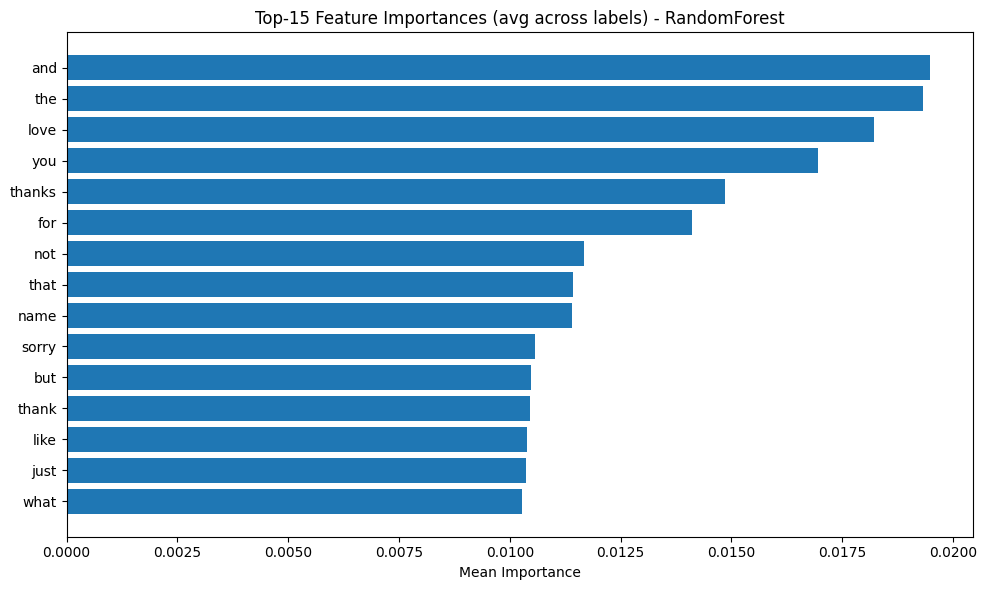

time: 9min 24s (started: 2026-02-11 10:10:52 -03:00)


In [41]:
plot_rf_feature_importance_smote(
    X_text=X_text_train,
    y=y_train,
    emotion_cols=emotion_cols,
    k=15
)

In [42]:
rows = []

for _, row in df_results.iterrows():
    model = row["Model"]
    for score in row["CV_F1_macro_all"]:
        rows.append({
            "Model": model,
            "F1_macro": score
        })

df_long = pd.DataFrame(rows)

df_pivot = df_long.pivot_table(
    index=df_long.groupby("Model").cumcount(),
    columns="Model",
    values="F1_macro"
)

stat, p_value = friedmanchisquare(
    *[df_pivot[col].values for col in df_pivot.columns]
)

print(f"Friedman chi2 = {stat:.4f}") # p >= 0.05 -> there is no overall statistical difference                    
print(f"p-value = {p_value:.6f}") # p < 0.05 -> at least one model is statistically different

alpha = 0.05
results_wilcoxon = []

models = df_pivot.columns.tolist()

for m1, m2 in itertools.combinations(models, 2):
    stat, p = wilcoxon(df_pivot[m1], df_pivot[m2])
    results_wilcoxon.append({
        "Model_1": m1,
        "Model_2": m2,
        "p_value": p,
    })

df_wilcoxon = pd.DataFrame(results_wilcoxon)

df_wilcoxon["p_corrected"] = multipletests(
    df_wilcoxon["p_value"],
    method="holm"
)[1]

df_wilcoxon["Significant"] = df_wilcoxon["p_corrected"] < alpha

df_wilcoxon.style.hide(axis="index")

Friedman chi2 = 2606.2468
p-value = 0.000000


Model_1,Model_2,p_value,p_corrected,Significant
LinearSVC,LogisticRegression,0.000000,0.000000,True
LinearSVC,RandomForest,0.000000,0.000000,True
LinearSVC,RidgeClassifier,0.000000,0.000000,True
LinearSVC,XGBClassifier,0.000000,0.000000,True
LogisticRegression,RandomForest,0.000000,0.000000,True
LogisticRegression,RidgeClassifier,0.000000,0.000000,True
LogisticRegression,XGBClassifier,0.000000,0.000000,True
RandomForest,RidgeClassifier,0.000000,0.000000,True
RandomForest,XGBClassifier,0.000000,0.000000,True
RidgeClassifier,XGBClassifier,0.000000,0.000000,True


time: 200 ms (started: 2026-02-11 10:20:16 -03:00)


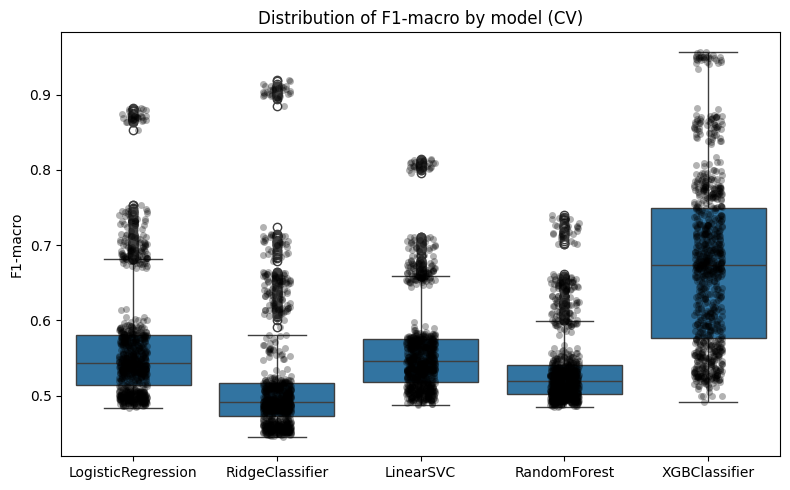

time: 162 ms (started: 2026-02-11 10:20:16 -03:00)


In [43]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_long,
    x="Model",
    y="F1_macro"
)
sns.stripplot(
    data=df_long,
    x="Model",
    y="F1_macro",
    color="black",
    alpha=0.3
)

plt.title("Distribution of F1-macro by model (CV)")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()

## (2) Class Weight

In [44]:
df['BASE_TEXT_PT'] = (
    df['BASE_TEXT_PT']
    .fillna("")
    .astype(str)
)

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

X_text = df['BASE_TEXT_PT']
y = df[emotion_cols].values

X_text_train, X_text_aux, y_train, y_aux = train_test_split(
    X_text, y,
    train_size=0.70,
    random_state=42,
)

X_text_dev, X_text_test, y_dev, y_test = train_test_split(
    X_text_aux, y_aux,
    train_size=0.50,
    random_state=42,
)

print(X_text_train.shape, X_text_dev.shape, X_text_test.shape)

(37963,) (8135,) (8136,)
time: 35.2 ms (started: 2026-02-11 10:20:17 -03:00)



Running model: LogisticRegression


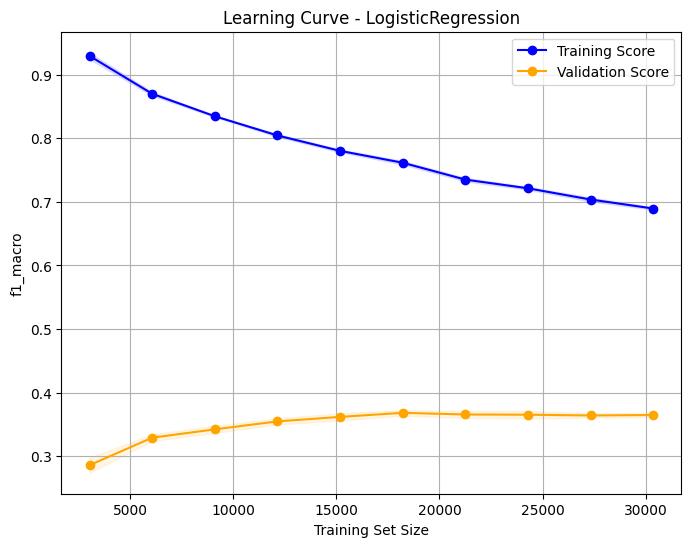


Running model: RidgeClassifier


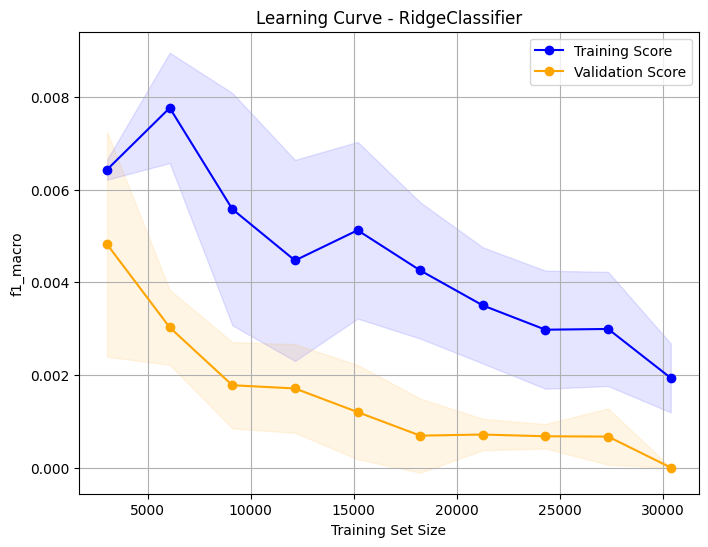


Running model: LinearSVC


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-d

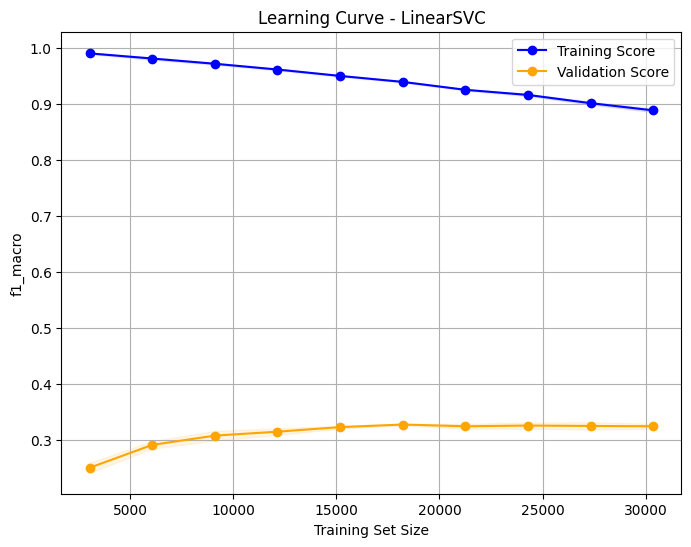


Running model: RandomForest


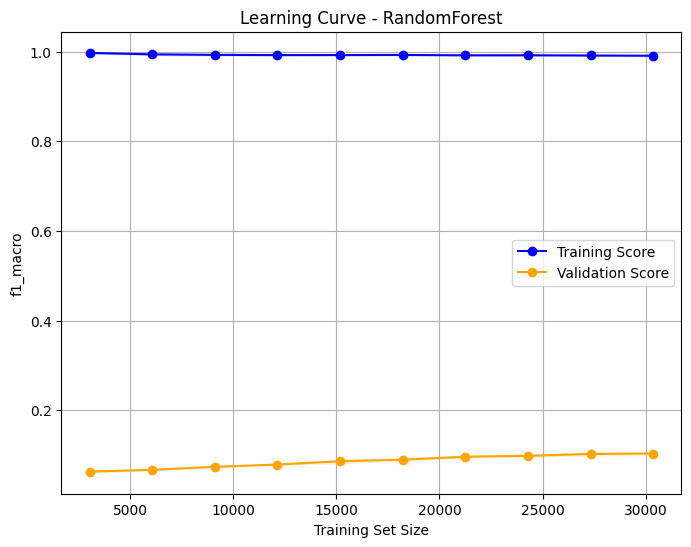

time: 3h 36min 56s (started: 2026-02-11 10:20:17 -03:00)


In [45]:
models_for_testing = {
    "LogisticRegression": OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")),
    "RidgeClassifier": RidgeClassifier(random_state=42, class_weight="balanced"),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42, class_weight="balanced")),
    "RandomForest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    # "XGBClassifier": OneVsRestClassifier(
    #     XGBClassifier(
    #         objective="binary:logistic",
    #         eval_metric="logloss",
    #         random_state=42,
    #         verbosity=0
    # ))
}

results = []

def run_predictions(name, model, X_text_train, y_train):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print("=" * 80)

    pipe = Pipeline([
        ("bow", CountVectorizer()),
        ("model", model)
    ])

    cv_res = evaluate_cv(clone(pipe), X_text_train, y_train, n_splits=5, n_repeats=6)

    plot_learning_curve(clone(pipe), X_text_train, y_train, model_name=name, cv=5, scoring="f1_macro")

    results.append({
        "Model": name,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],

        "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
        "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
        "CV_Precision_macro_all":   cv_res["Precision_macro"][2],

        "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
        "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
        "CV_Recall_macro_all":   cv_res["Recall_macro"][2],

        "CV_F1_macro_mean":  cv_res["F1_macro"][0],
        "CV_F1_macro_std":   cv_res["F1_macro"][1],
        "CV_F1_macro_all":   cv_res["F1_macro"][2],

        "CV_F1_weighted_mean":  cv_res["F1_weighted"][0],
        "CV_F1_weighted_std":   cv_res["F1_weighted"][1],
        "CV_F1_weighted_all":   cv_res["F1_weighted"][2],

        "CV_F1_micro_mean":  cv_res["F1_micro"][0],
        "CV_F1_micro_std":   cv_res["F1_micro"][1],
        "CV_F1_micro_all":   cv_res["F1_micro"][2],

        "CV_Hamming_loss_mean":  cv_res["Hamming_loss"][0],
        "CV_Hamming_loss_std":   cv_res["Hamming_loss"][1],
        "CV_Hamming_loss_all":   cv_res["Hamming_loss"][2],
    })

for name, model in models_for_testing.items():
    run_predictions(name, model, X_text_train, y_train)

In [46]:
df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_macro_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)

Best model: LogisticRegression
time: 2.89 ms (started: 2026-02-11 13:57:13 -03:00)


In [47]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro", "Hamming_loss"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        # Remove as colunas originais
        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    # reorganiza colunas
    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro", "Hamming_loss"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/balanced/balanced_05_GoEmotions_BoW_Class_Weight.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,F1_micro,Hamming_loss
LogisticRegression,0.1959 ± 0.0047,0.2913 ± 0.0037,0.5124 ± 0.0072,0.3649 ± 0.0041,0.4719 ± 0.0041,0.4414 ± 0.0036,0.0639 ± 0.0006
RidgeClassifier,0.0001 ± 0.0002,0.0045 ± 0.0107,0.0002 ± 0.0005,0.0004 ± 0.0006,0.0003 ± 0.0005,0.0004 ± 0.0008,0.0422 ± 0.0002
LinearSVC,0.185 ± 0.0034,0.2786 ± 0.0064,0.4013 ± 0.0086,0.3242 ± 0.0064,0.4278 ± 0.0036,0.4058 ± 0.0031,0.0621 ± 0.0005
RandomForest,0.1468 ± 0.004,0.4095 ± 0.025,0.0662 ± 0.0025,0.102 ± 0.0036,0.2081 ± 0.0041,0.2379 ± 0.0052,0.0398 ± 0.0003


time: 19.7 ms (started: 2026-02-11 13:57:13 -03:00)


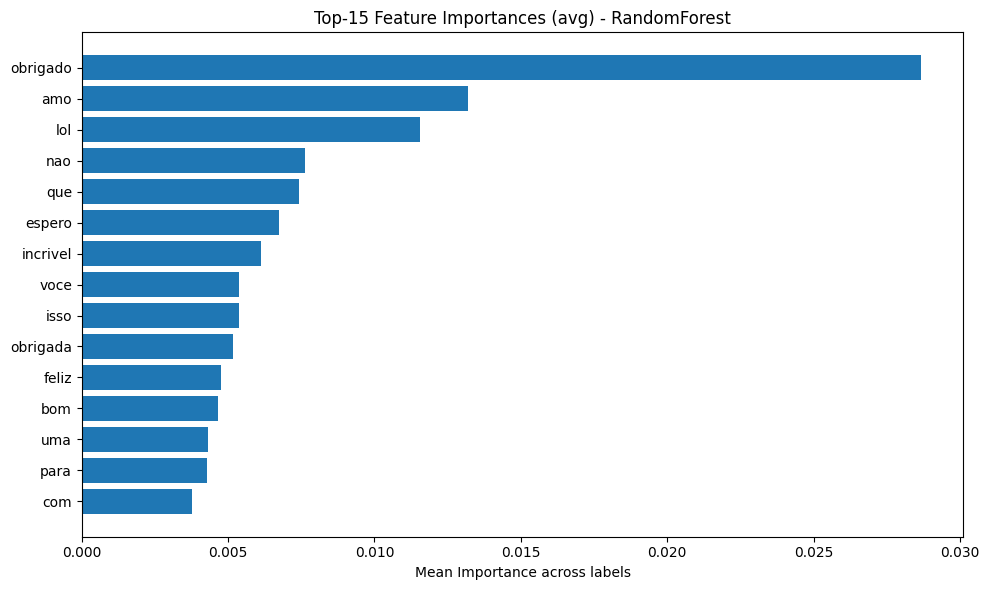

time: 3min 49s (started: 2026-02-11 13:57:14 -03:00)


In [48]:
pipe_rf = Pipeline([
    ("bow", CountVectorizer()),
    ("model", RandomForestClassifier(random_state=42))
])
pipe_rf.fit(X_text_train, y_train)

feature_names = pipe_rf["bow"].get_feature_names_out()
plot_feature_importance_top_k(pipe_rf["model"], feature_names, k=15, model_name="RandomForest")

In [49]:
rows = []

for _, row in df_results.iterrows():
    model = row["Model"]
    for score in row["CV_F1_macro_all"]:
        rows.append({
            "Model": model,
            "F1_macro": score
        })

df_long = pd.DataFrame(rows)

df_pivot = df_long.pivot_table(
    index=df_long.groupby("Model").cumcount(),
    columns="Model",
    values="F1_macro"
)

stat, p_value = friedmanchisquare(
    *[df_pivot[col].values for col in df_pivot.columns]
)

print(f"Friedman chi2 = {stat:.4f}") # p >= 0.05 -> there is no overall statistical difference                    
print(f"p-value = {p_value:.6f}") # p < 0.05 -> at least one model is statistically different

alpha = 0.05
results_wilcoxon = []

models = df_pivot.columns.tolist()

for m1, m2 in itertools.combinations(models, 2):
    stat, p = wilcoxon(df_pivot[m1], df_pivot[m2])
    results_wilcoxon.append({
        "Model_1": m1,
        "Model_2": m2,
        "p_value": p,
    })

df_wilcoxon = pd.DataFrame(results_wilcoxon)

df_wilcoxon["p_corrected"] = multipletests(
    df_wilcoxon["p_value"],
    method="holm"
)[1]

df_wilcoxon["Significant"] = df_wilcoxon["p_corrected"] < alpha

df_wilcoxon.style.hide(axis="index")

Friedman chi2 = 90.0000
p-value = 0.000000


Model_1,Model_2,p_value,p_corrected,Significant
LinearSVC,LogisticRegression,0.000000,0.000000,True
LinearSVC,RandomForest,0.000000,0.000000,True
LinearSVC,RidgeClassifier,0.000000,0.000000,True
LogisticRegression,RandomForest,0.000000,0.000000,True
LogisticRegression,RidgeClassifier,0.000000,0.000000,True
RandomForest,RidgeClassifier,0.000000,0.000000,True


time: 126 ms (started: 2026-02-11 14:01:03 -03:00)


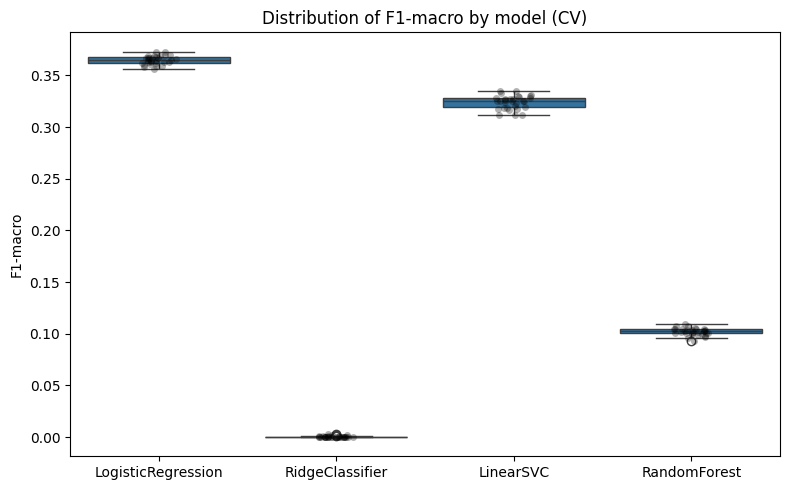

time: 130 ms (started: 2026-02-11 14:01:03 -03:00)


In [50]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_long,
    x="Model",
    y="F1_macro"
)
sns.stripplot(
    data=df_long,
    x="Model",
    y="F1_macro",
    color="black",
    alpha=0.3
)

plt.title("Distribution of F1-macro by model (CV)")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()